# Práctica 4: resultados y reflexión

Aquí reunimos la tabla de resultados, las gráficas y las respuestas al cuestionario.

In [1]:
from pathlib import Path
import sys
import os
import tempfile
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "endireh-matplotlib"))
PROYECTO = Path.cwd().resolve()
if PROYECTO.name == "notebooks":
    PROYECTO = PROYECTO.parent
if str(PROYECTO) not in sys.path:
    sys.path.insert(0, str(PROYECTO))
import polars as pl
from IPython.display import display, Image
from config.rutas import ARCHIVO_ENDIREH_PROCESADO, RUTA_FIGURAS
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_rows(40)
pl.Config.set_float_precision(4)
df = pl.read_parquet(ARCHIVO_ENDIREH_PROCESADO)
print(f"Registros: {df.height:,}, columnas: {df.width}, Polars {pl.__version__}")


Registros: 105,715, columnas: 31, Polars 1.44.2


In [2]:
from src.reporting.practica4 import resultados, tabla_markdown, metodologia, sintesis_texto, cuestionario
from IPython.display import Markdown
r = resultados()
display(Markdown("## Tabla de resultados\n\n" + tabla_markdown(r)))

## Tabla de resultados

| Familia | Variables | Valor obtenido | Interpretación |
|---|---|---|---|
| Localización | Edad de primera unión y número de hijos | edad_primer_union: media pond. 19.74, mediana pond. 17. num_hijos: media pond. 1.85, mediana pond. 1 | La edad usa los datos válidos. Hijos incluye los valores rellenados con cero. |
| Variabilidad | Edad de primera unión y número de hijos | edad_primer_union: CV 48.56%, IQR 13. num_hijos: CV 70.36%, IQR 2 | El IQR de edad es 13 años y el de hijos es 2. Ambos se calcularon sin ponderar. |
| Heterogeneidad | Violencia de pareja y estado civil | Violencia: H 0.6836, IQV 0.5945. Estado civil: H 2.2176, IQV 0.8945 | Muestra cómo se reparten las respuestas. No permite saber si hay subregistro. |
| Concentración | Casos ponderados por entidad | Gini 0.4180, área Lorenz 0.2910 | Los casos no se reparten por igual. También influye el tamaño de la población. |
| Gini vs. entropía | Estado civil (6 categorías), ponderado | H 2.2466 bits, Gini de frecuencias 0.3717 | Shannon mide diversidad y Gini mide desigualdad entre las frecuencias. |

In [3]:
display(Markdown("## Decisiones del análisis\n\n" + metodologia(r)))

## Decisiones del análisis

Usamos los datos de ENDIREH 2021 que limpiamos en la práctica 3. El archivo tiene 105,715 registros y 31 columnas. Trabajamos con Parquet y también guardamos una copia en CSV. Falta la edad en 95,764 registros (90.59%). No la rellenamos porque faltan demasiados datos. Los cálculos de edad usan los 9,951 registros que sí tienen dato. En hijos se rellenaron 19,231 valores con cero en la práctica 3. Esa decisión puede afectar los resultados. Elegimos edad e hijos para describir las características demográficas. Para heterogeneidad usamos escolaridad, estado civil y condiciones económicas. Para concentración agrupamos por entidad. Usamos Polars para cargar y agrupar los datos, NumPy para los índices y SciPy para el CV con stats.variation y ddof=1. Las gráficas se hicieron con Matplotlib y Seaborn. Las funciones de los índices están en src/analysis/indices.py. Los notebooks reúnen los cálculos y las interpretaciones. Git guarda los cambios del proyecto. La media y la mediana ponderadas usan factor_expansion. Para la mediana ordenamos los valores y tomamos el primero cuyo peso acumulado llega al 50%. La variabilidad y la heterogeneidad se calcularon sin ponderar para describir la muestra. Los casos por entidad y sus porcentajes sí usan el factor de expansión. En la comparación de Gini y Shannon calculamos una versión sin ponderar y otra ponderada para ver la diferencia.

## Visualizaciones e interpretación

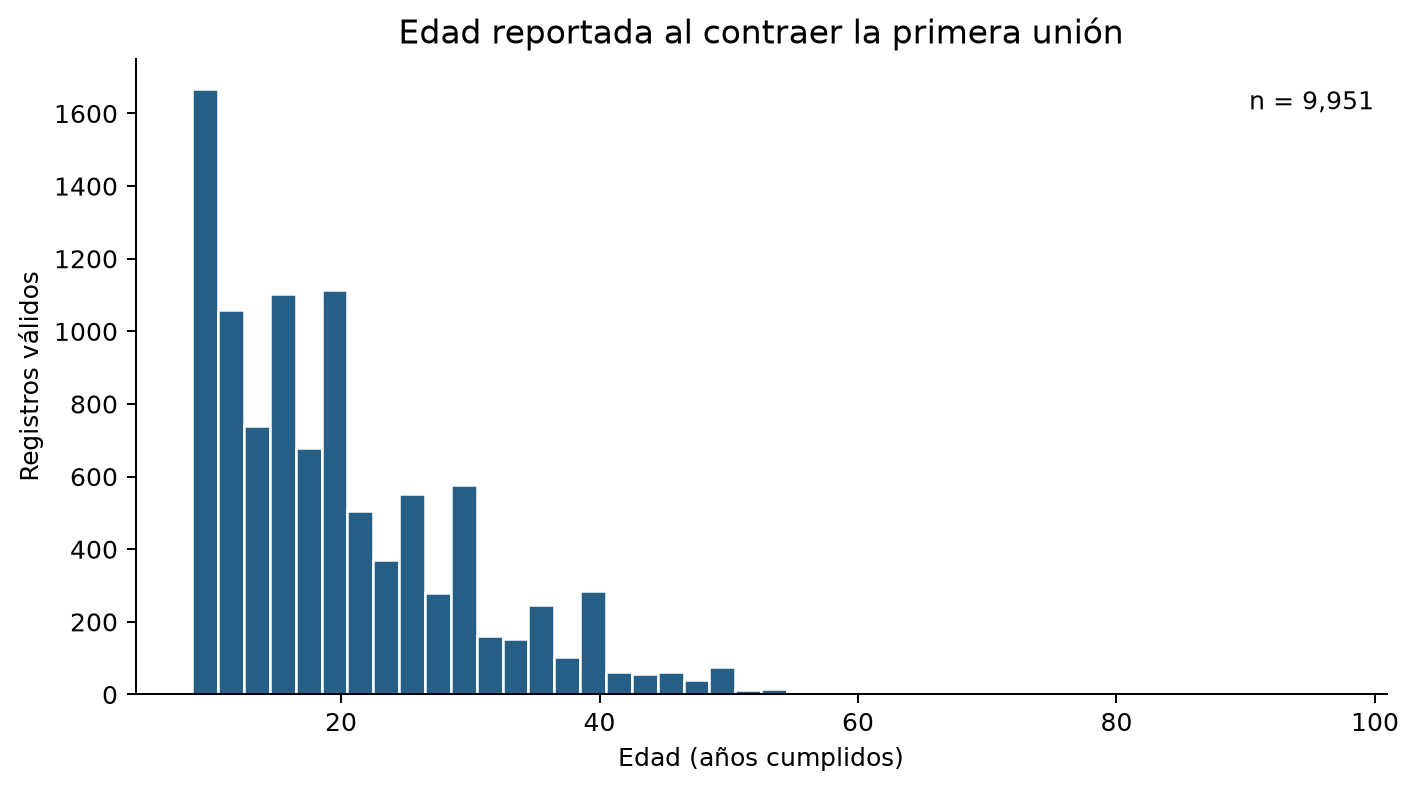

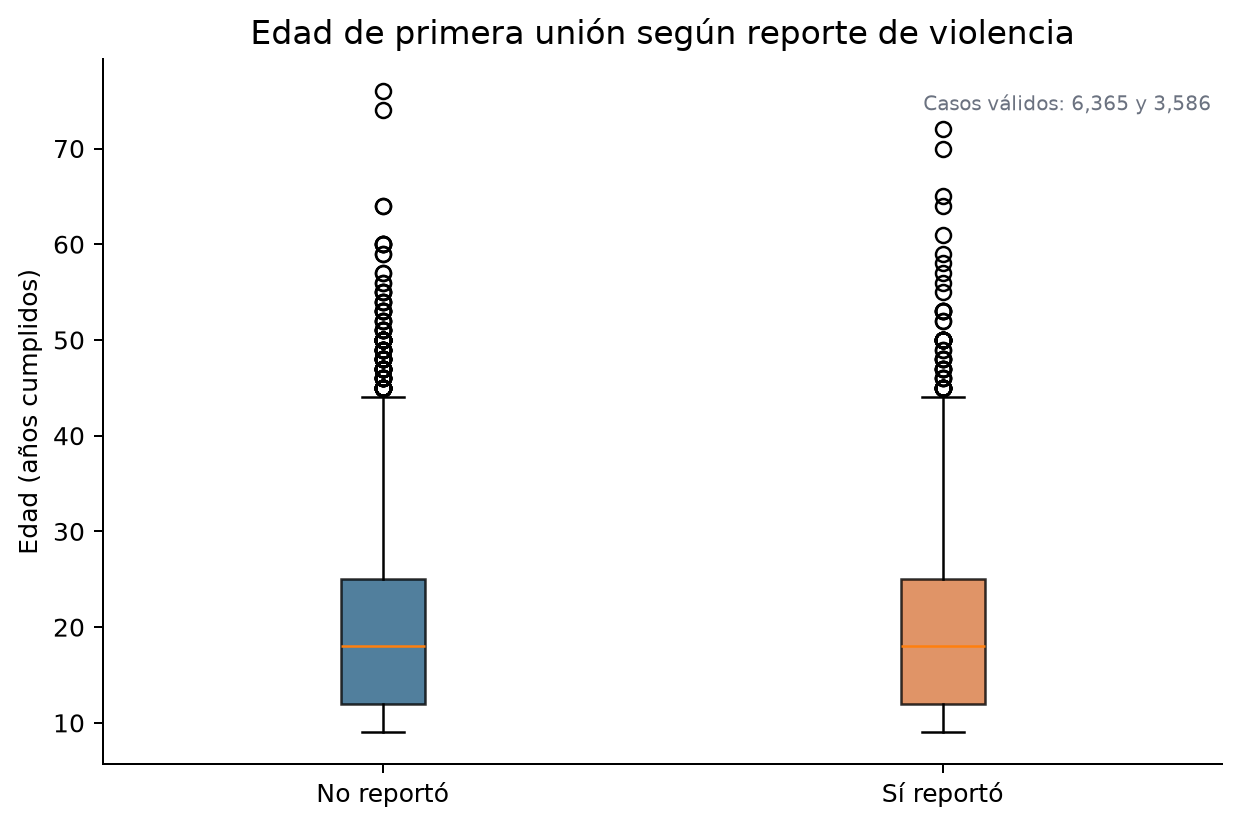

In [4]:
for nombre in ['02_distribucion_edad.png', '05_edad_por_violencia.png']:
    display(Image(filename=RUTA_FIGURAS / nombre, width=850))

El histograma y los boxplots usan los datos válidos de edad sin ponderar. Los dos grupos tienen mediana de 18 años e IQR de 13. Como hay valores altos y muchos datos faltantes, el promedio no basta para describir la distribución.

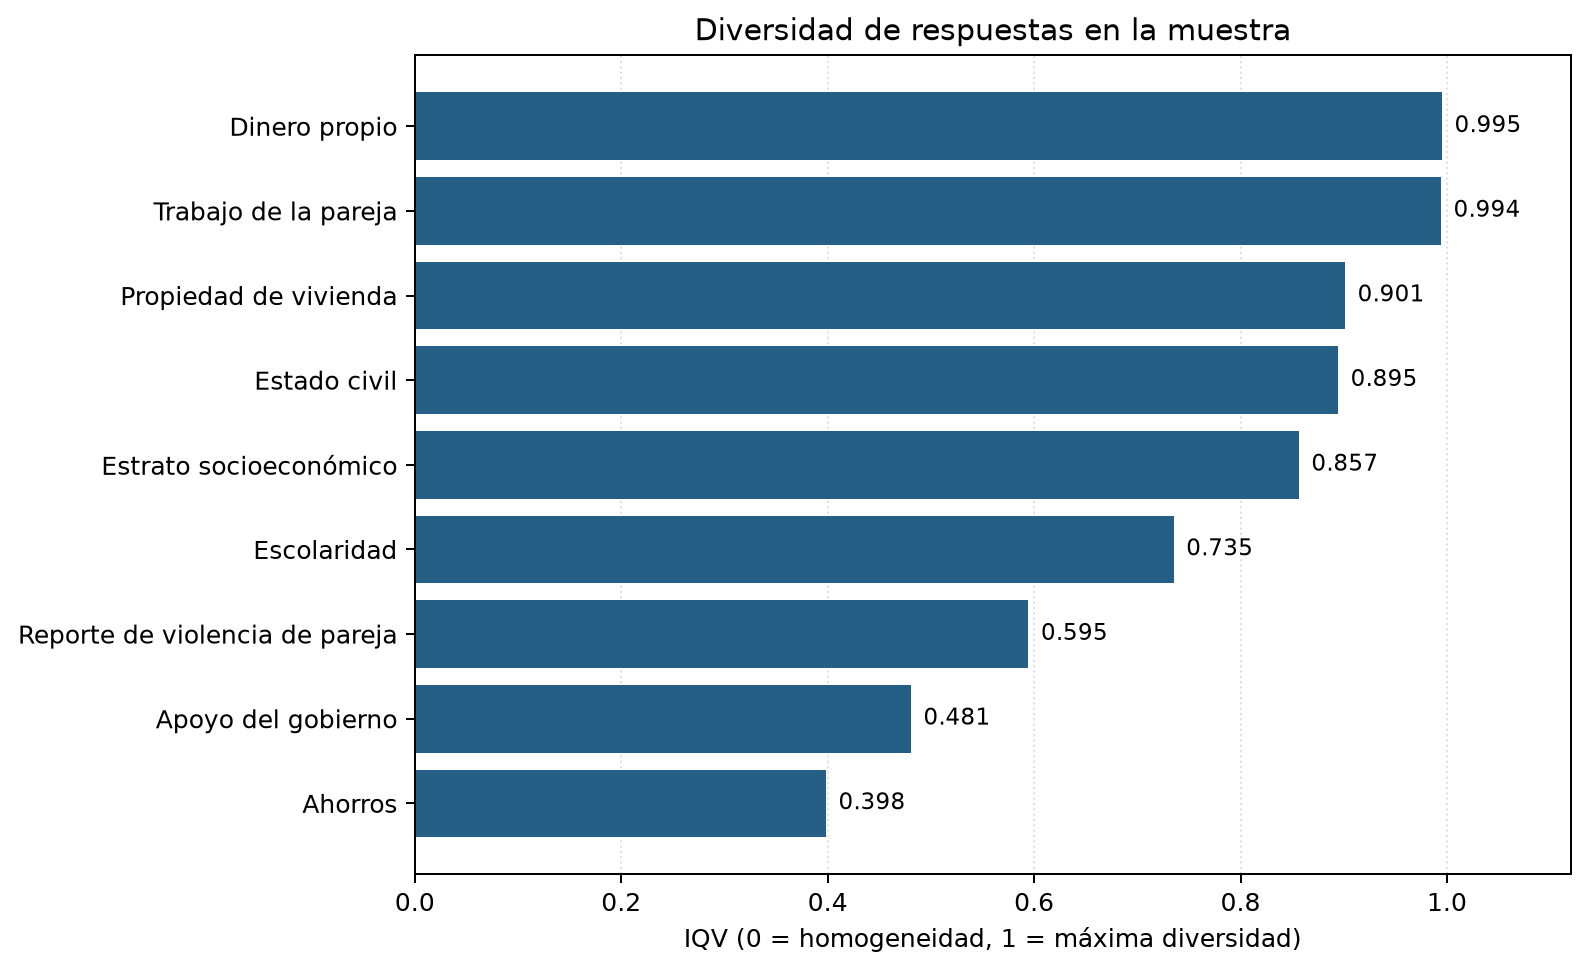

In [5]:
for nombre in ['07_barras_iqv.png']:
    display(Image(filename=RUTA_FIGURAS / nombre, width=850))

Las respuestas de dinero propio y trabajo de la pareja están casi equilibradas. En ahorros hay menos diversidad porque predomina una de las respuestas. Estos índices muestran cómo se reparten las categorías, pero no nos dicen qué grupos tienen mayor riesgo de violencia.

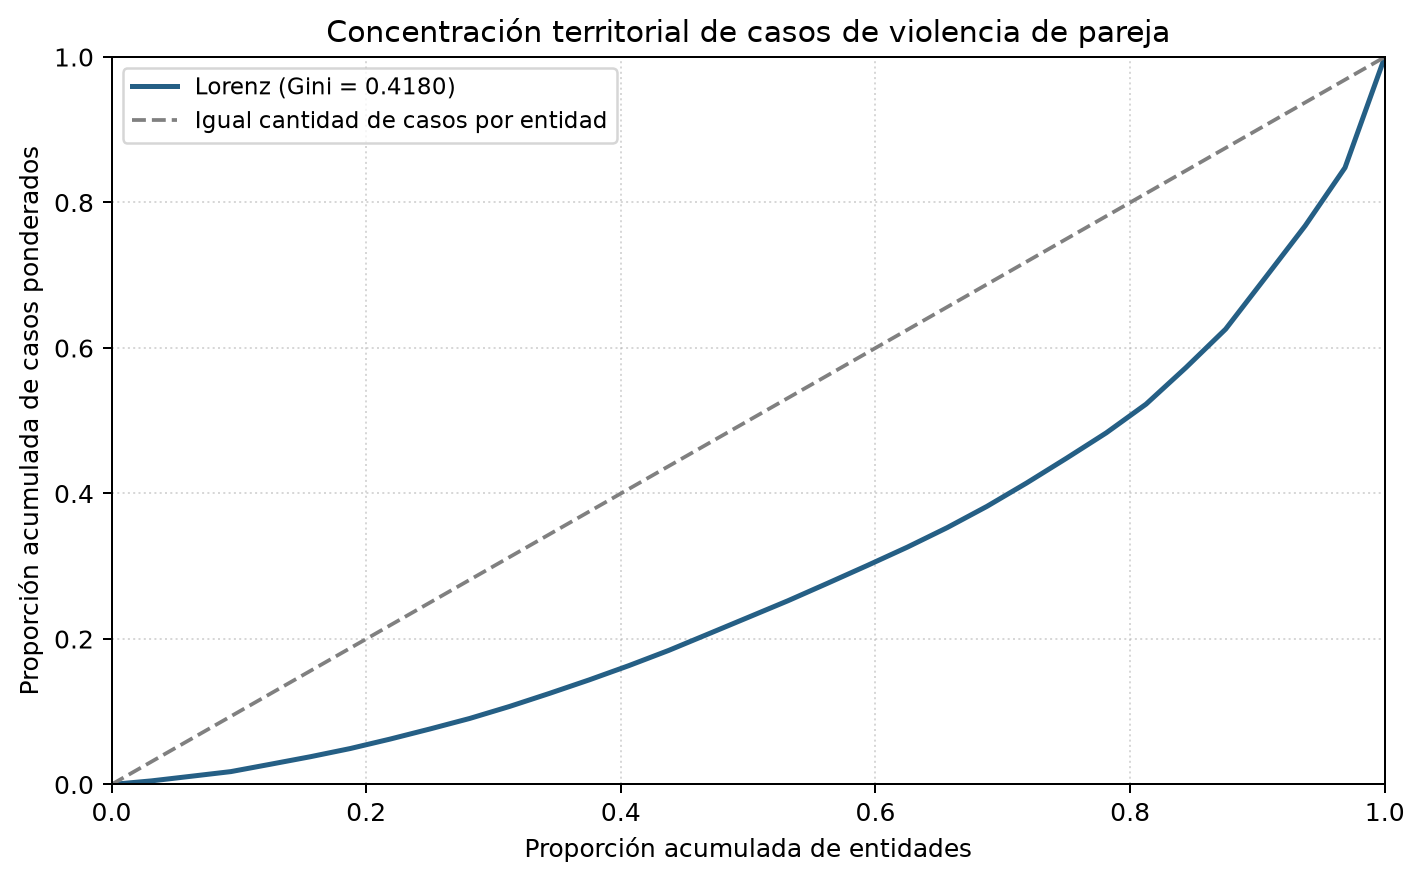

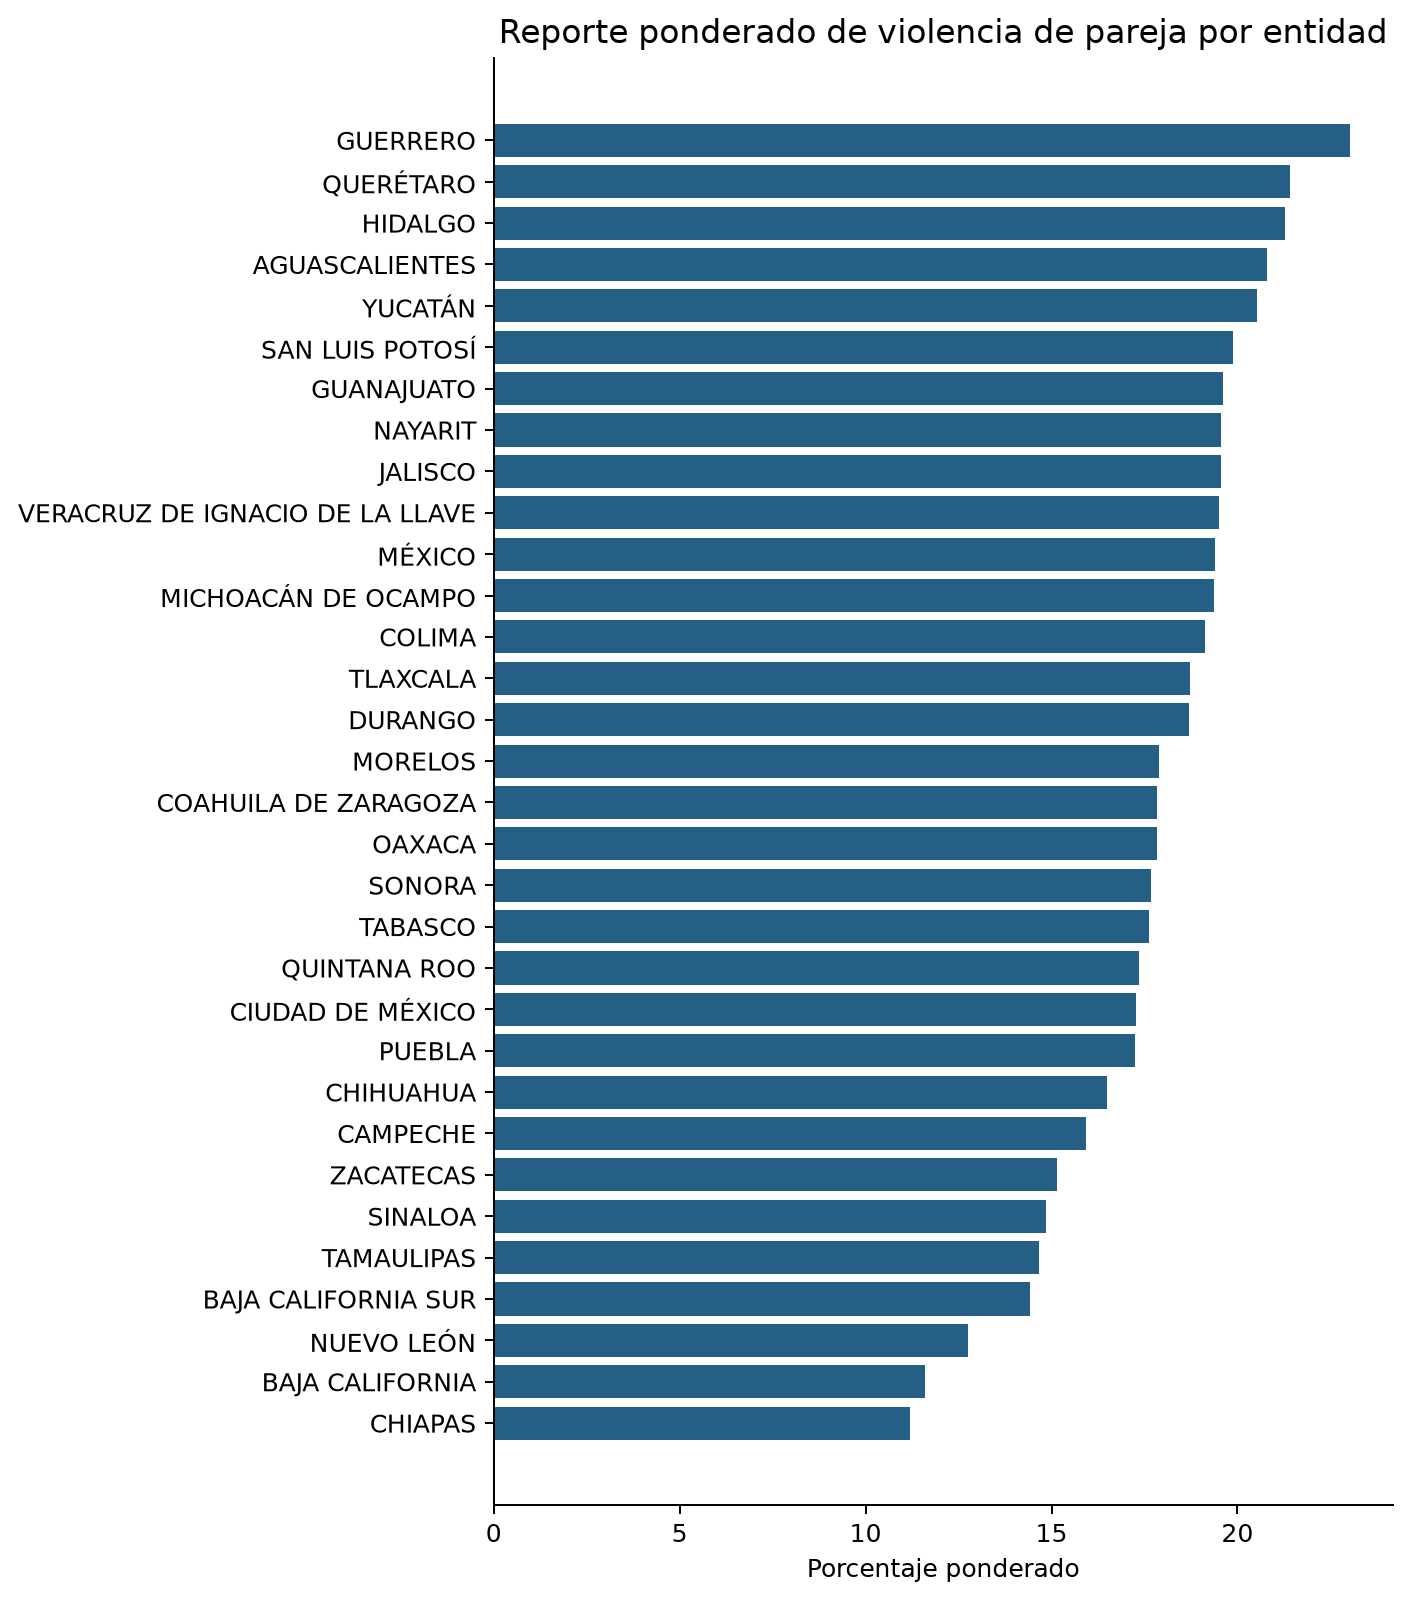

In [6]:
for nombre in ['08_curva_lorenz.png', '06_violencia_por_entidad.png']:
    display(Image(filename=RUTA_FIGURAS / nombre, width=850))

Lorenz muestra cómo se reparten los casos ponderados entre las entidades. La otra gráfica muestra el porcentaje de violencia dentro de cada entidad. No miden lo mismo, ya que una entidad con más población puede tener más casos sin tener un porcentaje más alto.

In [7]:
display(Markdown("## Comparación de Gini y entropía\n\n" + sintesis_texto(r)))

## Comparación de Gini y entropía

Para estado civil obtuvimos una entropía ponderada de 2.2466 bits y un Gini de frecuencias de 0.3717. Shannon muestra qué tan repartidas están las respuestas entre las seis categorías. Su máximo es log2(6), aproximadamente 2.5850. El Gini muestra qué tan desiguales son las frecuencias de esas categorías. Los dos usan los mismos datos, pero responden preguntas distintas. Sin ponderar, Shannon es 2.2176. La diferencia se debe al factor de expansión. Estos índices no muestran la relación entre estado civil y violencia. Tampoco hay que confundir el Gini de concentración con Gini-Simpson, que mide diversidad.

In [8]:
display(Markdown("## Cuestionario\n\n" + "\n\n".join("### " + p + "\n\n" + t for p, t in cuestionario(r))))

## Cuestionario

### 1. ¿Qué muestran Lorenz y Gini?

Obtuvimos un Gini de 0.4180 y la curva quedó por debajo de la diagonal. Esto muestra que los casos ponderados no se reparten por igual entre las entidades. Sin embargo, sus poblaciones son distintas. Tener más casos no significa necesariamente tener un porcentaje mayor de violencia. Por eso también revisamos el porcentaje de cada entidad. El Gini que calculamos resume la concentración entre todas las entidades, no es un índice para cada estado.

### 2. Limitaciones y mejoras concretas

Una limitación es la cantidad de edades faltantes. Otra es haber rellenado hijos con cero, porque eso puede cambiar su distribución. También eliminamos duplicados sin tener un identificador de entrevista que permita comprobar cada caso. Las respuestas de la encuesta dependen de lo que las personas estén dispuestas a contar, pero estos cálculos no permiten saber cuánto subregistro hay. Como mejoras, revisaríamos los códigos y las preguntas del cuestionario y compararíamos los resultados de hijos con y sin los ceros imputados. También buscaríamos identificadores y variables del diseño muestral para revisar los duplicados y calcular intervalos de confianza. Para analizar municipios primero habría que revisar si hay suficientes datos y cuidar la privacidad de las personas.

### 3. ¿Cómo orientan decisiones posteriores?

Las medidas de localización y variabilidad ayudan a revisar los valores extremos y las decisiones de limpieza. La heterogeneidad permite ver qué variables tienen categorías equilibradas y en cuáles predomina una respuesta. La concentración ayuda a ver dónde se acumulan más casos, pero para decidir dónde hacen falta recursos también hay que revisar los porcentajes y el tamaño de la población. Para elegir variables de un modelo necesitaríamos estudiar su relación con la violencia y validar sus resultados. Estas medidas no bastan para identificar causas o grupos con mayor riesgo.

### 4. Consideraciones éticas y de comunicación

Al presentar las gráficas hay que explicar qué datos usamos, cómo se ponderaron y qué valores faltan o se rellenaron. Debemos distinguir las respuestas de la encuesta de las denuncias y los totales de casos de los porcentajes. No sería correcto llamar violentos a ciertos estados ni asumir que en los que tienen menos casos el problema es menor. Si analizamos grupos más pequeños, tenemos que cuidar su privacidad. Los resultados son del archivo del curso y no deben presentarse como cifras oficiales de INEGI.

## Reporte PDF

Para generar el reporte ejecutamos `python -m src.reporting.practica4` desde la raíz del proyecto. El PDF queda en `output/pdf/AyMD_Reporte_P4.pdf`.

Los datos son de ENDIREH 2021 y usamos el archivo que se proporcionó para el curso.